--
# DATA MINING ASSIGNMENT 2 - 
# Recommender Systems 

---
## Step 1: Data preprocessing



### 0. Import & configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# paths creation need to adapt with yours

path = r'C:\Users\ephts\OneDrive\Documents\Master UA\Data mining\A2' 

data_path = os.path.join(path, 'datas') 
output = os.path.join(path, 'output') 
preprocessed = os.path.join(path, 'preprocessed') 
figures = os.path.join(path, 'fig') 

MOVIES_PATH = os.path.join(data_path, 'movies.csv') 
RATINGS_TRAIN_PATH = os.path.join(data_path, 'ratings_train.csv') 
RATINGS_TEST_PATH = os.path.join(data_path, 'ratings_test.csv')

print('Imported and paths created')

Imported and paths created


---
### 1. Loading tables

In [4]:
movies = pd.read_csv(MOVIES_PATH) 
ratings_train = pd.read_csv(RATINGS_TRAIN_PATH) 
ratings_test = pd.read_csv(RATINGS_TEST_PATH) 

print('Datas loaded') 
print("------MOVIES--------") 
print(f'movies : {movies.shape}') 
display(movies.head()) 

print("------RATINGS TRAIN--------") 
print(f'ratings_train : {ratings_train.shape}') 
display(ratings_train.head()) 

print("------RATINGS TEST--------") 
print(f'ratings_test : {ratings_test.shape}') 
display(ratings_test.head())

Datas loaded
------MOVIES--------
movies : (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


------RATINGS TRAIN--------
ratings_train : (97801, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


------RATINGS TEST--------
ratings_test : (100, 11)


,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
### 2. First explorations

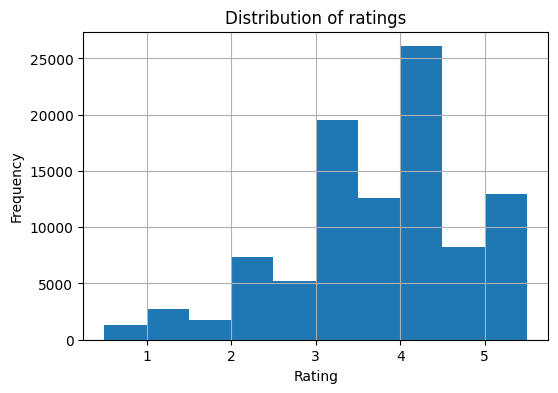

In [5]:
# Rating distribution
filename = "rating_distrib.png"
save_path = os.path.join(figures, filename)
plt.figure(figsize=(6,4))
ratings_train['rating'].hist(bins=np.arange(0.5, 5.6, 0.5))
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of ratings')
plt.savefig(save_path)
plt.show()

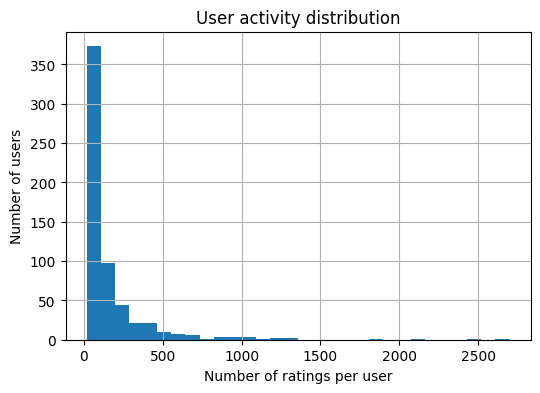

In [6]:
# Number of ratings per user
filename = "rating_per_usr.png"
save_path2 = os.path.join(figures, filename)

user_activity = ratings_train.groupby('userId').size()

plt.figure(figsize=(6,4))
user_activity.hist(bins=30)
plt.xlabel('Number of ratings per user')
plt.ylabel('Number of users')
plt.title('User activity distribution')
plt.savefig(save_path2)
plt.show()

In [14]:
# Movie popularity
movie_popularity = ratings_train.groupby('movieId').size().sort_values(ascending=False)

print('Most rated movies:')
display(movie_popularity.head(10))

Most rated movies:


movieId
356     326
318     309
296     303
593     276
2571    271
260     244
480     234
110     233
589     219
527     218
dtype: int64

In [15]:
#Activity statistics

user_rating_counts = ratings_train.groupby('userId').size()
movie_rating_counts = ratings_train.groupby('movieId').size()

print("----- USER ACTIVITY -----")
print(user_rating_counts.describe())

print("\n----- MOVIE POPULARITY -----")
print(movie_rating_counts.describe())

print(f"Users with 0 or only 1 rating  : {(user_rating_counts <= 1).sum()}")
print(f"Users with strictly more than 1 rating  : {(user_rating_counts > 1).sum()}")
print(f"Movies with only 1 rating : {(movie_rating_counts == 1).sum()}")

----- USER ACTIVITY -----
count     600.000000
mean      163.001667
std       268.379291
min        19.000000
25%        35.000000
50%        69.500000
75%       167.000000
max      2698.000000
dtype: float64

----- MOVIE POPULARITY -----
count    9680.000000
mean       10.103409
std        21.750935
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       326.000000
dtype: float64
Users with 0 or only 1 rating  : 0
Users with strictly more than 1 rating  : 600
Movies with only 1 rating : 3424


---
### 3. Checking for missing, values, duplicate,..

In [16]:
# Missing values

print("----- MISSING VALUES -----")
print("movies")
display(movies.isnull().sum())

print("\nratings_train")
display(ratings_train.isnull().sum())

print("\nratings_test")
display(ratings_test.isnull().sum())

----- MISSING VALUES -----
movies


movieId    0
title      0
genres     0
dtype: int64


ratings_train


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


ratings_test


userId                0
recommendation1     100
recommendation2     100
recommendation3     100
recommendation4     100
recommendation5     100
recommendation6     100
recommendation7     100
recommendation8     100
recommendation9     100
recommendation10    100
dtype: int64

In [17]:
### Duplicates

print("----- DUPLICATES -----")
print(f"Duplicate rows in movies       : {movies.duplicated().sum()}")
print(f"Duplicate rows in ratings_train: {ratings_train.duplicated().sum()}")
print(f"Duplicate rows in ratings_test : {ratings_test.duplicated().sum()}")

----- DUPLICATES -----
Duplicate rows in movies       : 0
Duplicate rows in ratings_train: 0
Duplicate rows in ratings_test : 0


In [18]:
# Check for unique values
n_users = ratings_train['userId'].nunique() 
n_movies = ratings_train['movieId'].nunique() 
n_ratings = len(ratings_train) 
sparsity = 1 - n_ratings / (n_users * n_movies) 

print(f'Unique users : {n_users}') 
print(f'Unique movies : {n_movies}') 
print(f'Total ratings : {n_ratings}') 
print(f'Rating range : {ratings_train["rating"].min()} – {ratings_train["rating"].max()}') 
print(f'Matrix sparsity: {sparsity:.2%}')

Unique users : 600
Unique movies : 9680
Total ratings : 97801
Rating range : 0.5 – 5.0
Matrix sparsity: 98.32%


In [19]:
# Check repeated user-movie pairs

user_movie_duplicates = ratings_train.duplicated(subset=['userId', 'movieId']).sum()
print(f"Duplicate (userId, movieId) pairs in ratings_train: {user_movie_duplicates}")

Duplicate (userId, movieId) pairs in ratings_train: 0


---
### 4. Preprocessing - movies.csv

In [20]:

# Extract year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

# One-hot encode genres (needed only for cold start fallback)
all_genres = sorted(set(
    g for sublist in movies['genres'].str.split('|')
    for g in sublist if g != '(no genres listed)'
))
for genre in all_genres:
    movies[f'genre_{genre}'] = movies['genres'].str.contains(genre, regex=False).astype(int)

print(f'Genres encoded ({len(all_genres)}): {all_genres}')
print(f'Films without genre: {(movies["genres"] == "(no genres listed)").sum()}')
display(movies[['movieId', 'title_clean', 'year', 'genres']].head())

Genres encoded (19): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Films without genre: 34


,movieId,title_clean,year,genres
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II,1995.0,Comedy


---
### 5. Preprocessing rating_train.csv

In [21]:
# Drop timestamp: not needed for collaborative filtering or SVD
ratings_train.drop(columns=['timestamp'], inplace=True)

display(ratings_train.head())

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


---
### 6. Saving tables

In [22]:
movies.to_csv(os.path.join(preprocessed, "movies.csv"), index=False)
ratings_train.to_csv(os.path.join(preprocessed, "rating_train.csv"), index=False)

print('Files saved')

Files saved
